# Pneumonia Detection from Chest X-Rays
### CNN Image Classifier — Problem Set 01

**Goal:** Build a CNN model that classifies chest X-ray images as either **NORMAL** or **PNEUMONIA**.

---
**Steps we'll follow:**
1. Mount Google Drive & load dataset
2. Explore & visualize the data
3. Preprocess & augment images
4. Build CNN model
5. Train the model
6. Evaluate performance
7. Visualize results

##  Step 1: Install & Import Libraries

In [1]:

!pip install tensorflow matplotlib seaborn scikit-learn -q

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


##  Step 2: Mount Google Drive
>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully!')

Mounted at /content/drive
Google Drive mounted successfully!


## Step 3: Download Dataset from Google Drive Link
>

In [3]:
# Install gdown to download from Google Drive
!pip install gdown -q
import gdown

# Download the dataset ZIP file
file_id = '1219EeGE1XTJVXYaulynJSa3BXGsbNCLx'
output = '/content/chest_xray.zip'

print('Downloading dataset...')
gdown.download(f'https://drive.google.com/uc?id={file_id}', output, quiet=False)
print('Download complete!')

Downloading...
From (original): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx
From (redirected): https://drive.google.com/uc?id=1219EeGE1XTJVXYaulynJSa3BXGsbNCLx&confirm=t&uuid=2a84d6fd-69c6-495f-bd4f-4b39d140878a
To: /content/chest_xray.zip
100%|██████████| 1.23G/1.23G [00:20<00:00, 61.1MB/s]

Download complete!


In [4]:
# Extract the ZIP file
import zipfile

print('Extracting files...')
with zipfile.ZipFile('/content/chest_xray.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print('Extraction complete!')

# List extracted folders
!ls /content/

Extracting files...
Extraction complete!
chest_xray.zip	drive  __MACOSX  sample_data  test  train  val


## Step 4: Set Dataset Paths

In [5]:

BASE_DIR = '/content'

TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
VAL_DIR   = os.path.join(BASE_DIR, 'val')

# Count images in each folder
for split, path in [('TRAIN', TRAIN_DIR), ('TEST', TEST_DIR), ('VAL', VAL_DIR)]:
    for label in ['NORMAL', 'PNEUMONIA']:
        folder = os.path.join(path, label)
        count = len(os.listdir(folder))
        print(f'  {split} | {label}: {count} images')

  TRAIN | NORMAL: 1341 images
  TRAIN | PNEUMONIA: 3875 images
  TEST | NORMAL: 234 images
  TEST | PNEUMONIA: 390 images
  VAL | NORMAL: 8 images
  VAL | PNEUMONIA: 8 images


## Step 5: Visualize Sample Images

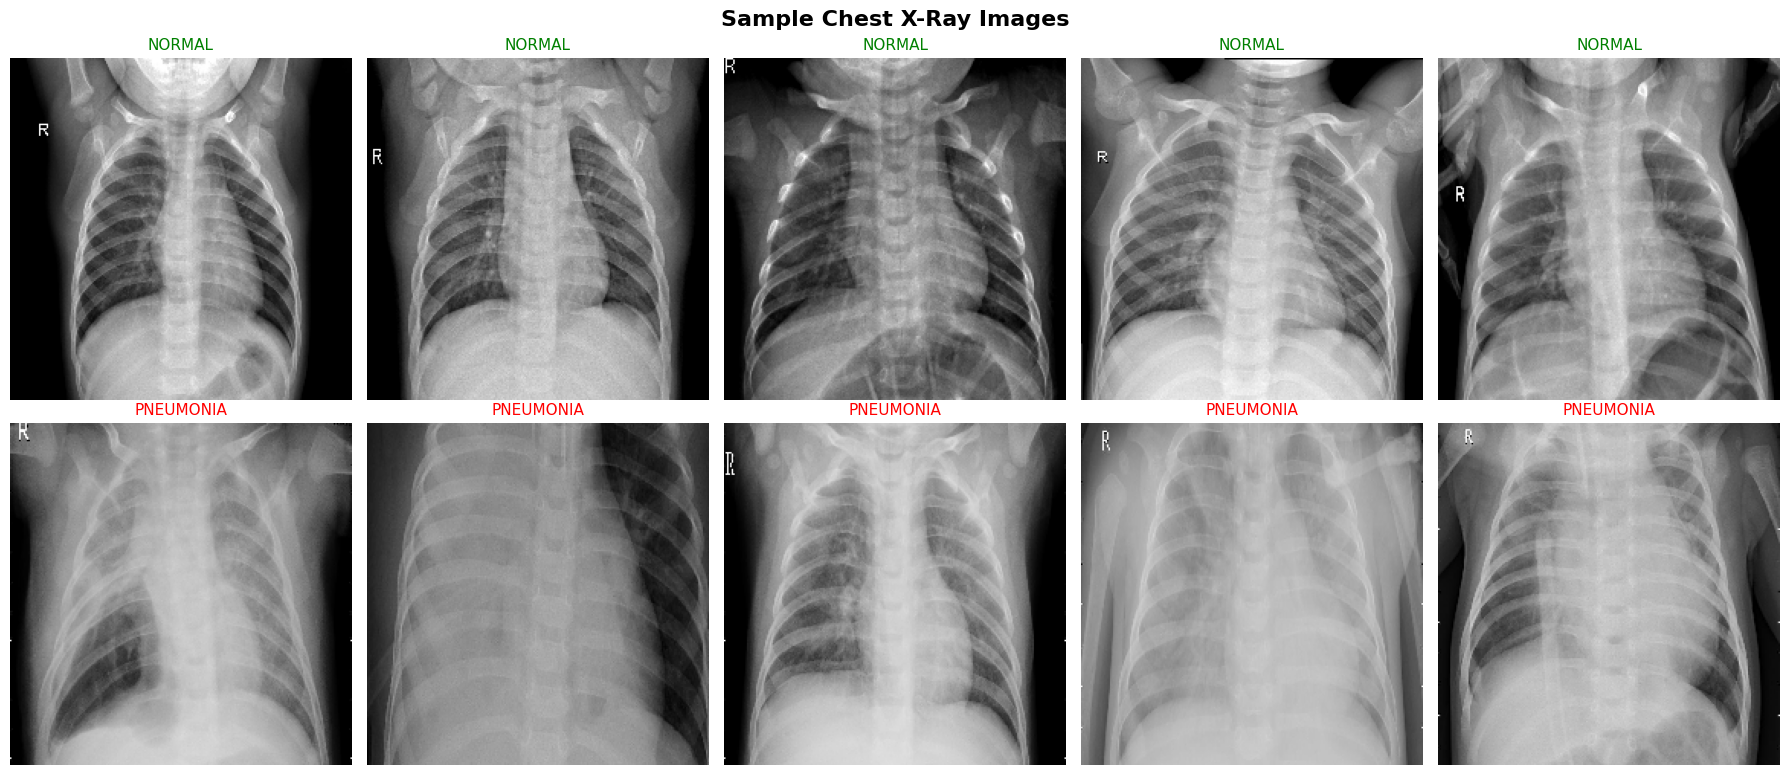

In [6]:
from tensorflow.keras.preprocessing.image import load_img

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Sample Chest X-Ray Images', fontsize=16, fontweight='bold')

for idx, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(TRAIN_DIR, label)
    images = os.listdir(folder)[:5]
    for j, img_name in enumerate(images):
        img = load_img(os.path.join(folder, img_name), target_size=(224, 224))
        axes[idx][j].imshow(img, cmap='gray')
        axes[idx][j].set_title(label, fontsize=11,
                                color='green' if label == 'NORMAL' else 'red')
        axes[idx][j].axis('off')

plt.tight_layout()
plt.show()

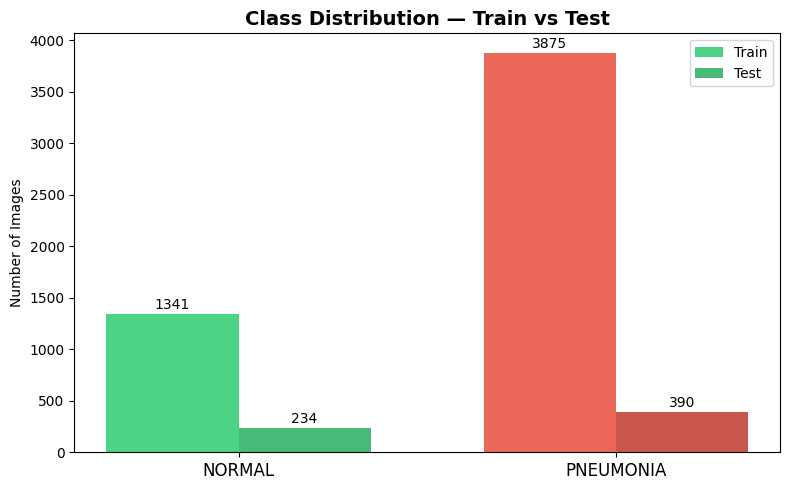

In [7]:
# Class distribution bar chart
labels = ['NORMAL', 'PNEUMONIA']
train_counts = [len(os.listdir(os.path.join(TRAIN_DIR, l))) for l in labels]
test_counts  = [len(os.listdir(os.path.join(TEST_DIR, l)))  for l in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, train_counts, width, label='Train', color=['#2ecc71','#e74c3c'], alpha=0.85)
bars2 = ax.bar(x + width/2, test_counts,  width, label='Test',  color=['#27ae60','#c0392b'], alpha=0.85)

ax.set_title('Class Distribution — Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Number of Images')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Step 6: Data Preprocessing & Augmentation

In [8]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# Training data — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test data — only rescale, no augmentation
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    color_mode='rgb',
    shuffle=False  # Important: keep order for evaluation
)

print('\nClass indices:', train_generator.class_indices)
print('   0 = NORMAL, 1 = PNEUMONIA')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
   0 = NORMAL, 1 = PNEUMONIA


## Step 7: Build the CNN Model (Transfer Learning with VGG16)
> We use **VGG16** — a powerful pre-trained model trained on millions of images. We freeze its base and add our own classification layers on top.

In [9]:
# Load VGG16 base (pre-trained on ImageNet, without top layers)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model layers (don't retrain them)
base_model.trainable = False

# Build our complete model
model = models.Sequential([
    base_model,

    # Flatten the output
    layers.GlobalAveragePooling2D(),

    # Dense layers
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Output layer — binary classification
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,577 (56.76 MB)

 Trainable params: 165,121 (645.00 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

## Step 8: Set Up Callbacks & Train the Model

In [10]:
callbacks = [
    # Stop training if val_loss doesn't improve for 5 epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),

    # Save the best model automatically
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),

    # Reduce learning rate if stuck
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
]

# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

# Train the model
print('\n Starting training...')
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print('\n Training complete!')

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

 Starting training...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 667ms/step - accuracy: 0.6654 - auc: 0.7674 - loss: 0.6616 - precision: 0.8908 - recall: 0.6272
Epoch 1: val_accuracy improved from None to 0.56250, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 723ms/step - accuracy: 0.7291 - auc: 0.8589 - loss: 0.5330 - precision: 0.9371 - recall: 0.6810 - val_accuracy: 0.5625 - val_auc: 0.8594 - val_loss: 0.6281 - val_precision: 0.5333 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.8100 - auc: 0.9333 - loss: 0.3753 - precision: 0.9731 - recall: 0.7646
Epoch 2: val_accuracy improved from 0.56250 to 0.75000, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 689ms/step - accuracy: 0.8227 - auc: 

##  Step 9: Fine-Tuning (Unfreeze last VGG16 layers)

In [11]:
# Unfreeze the last 4 layers of VGG16 for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with a lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

print('Fine-tuning last 4 VGG16 layers...')
history_ft = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print('\n Fine-tuning complete!')

Fine-tuning last 4 VGG16 layers...
Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.9287 - auc: 0.9794 - loss: 0.1862 - precision: 0.9818 - recall: 0.9217
Epoch 1: val_accuracy did not improve from 0.87500
163/163 ━━━━━━━━━━━━━━━━━━━━ 127s 708ms/step - accuracy: 0.9379 - auc: 0.9827 - loss: 0.1691 - precision: 0.9839 - recall: 0.9316 - val_accuracy: 0.8125 - val_auc: 1.0000 - val_loss: 0.3455 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.9389 - auc: 0.9895 - loss: 0.1357 - precision: 0.9861 - recall: 0.9310
Epoch 2: val_accuracy did not improve from 0.87500
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 693ms/step - accuracy: 0.9446 - auc: 0.9892 - loss: 0.1349 - precision: 0.9851 - recall: 0.9396 - val_accuracy: 0.8750 - val_auc: 0.9844 - val_loss: 0.2868 - val_precision: 1.0000 - val_recall: 0.7500 - learning_rate: 1.0000e-05
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - acc

##  Step 10: Plot Training History

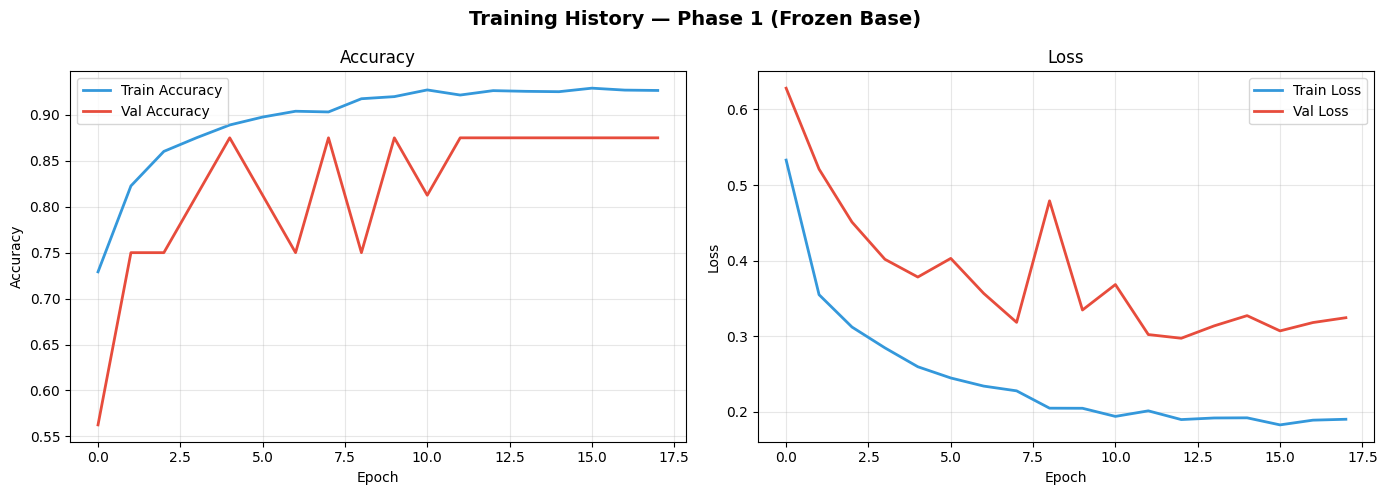

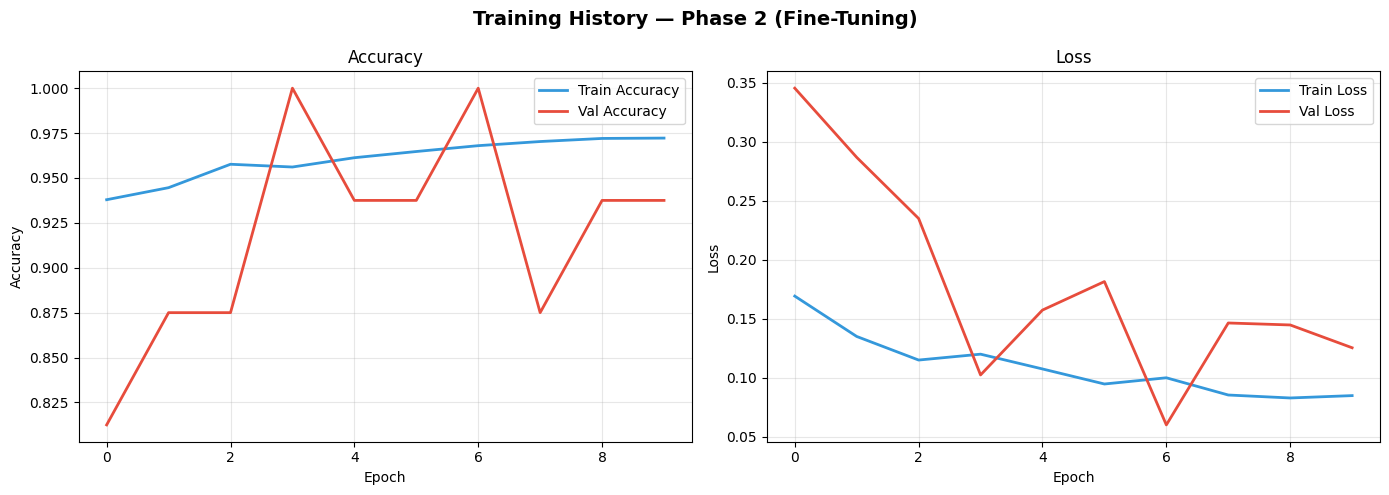

In [12]:
def plot_history(history, title_suffix=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History {title_suffix}', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='#3498db', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c', linewidth=2)
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history,    '— Phase 1 (Frozen Base)')
plot_history(history_ft, '— Phase 2 (Fine-Tuning)')

## Step 11: Evaluate on Test Set

In [13]:
# Load best saved model
model = keras.models.load_model('best_model.keras')

# Evaluate
print('Evaluating on Test Set...')
results = model.evaluate(test_generator, verbose=1)
metric_names = ['Loss', 'Accuracy', 'Precision', 'Recall', 'AUC']

print('\n' + '='*45)
print('         TEST SET PERFORMANCE')
print('='*45)
for name, value in zip(metric_names, results):
    print(f'  {name:<12}: {value:.4f}')
print('='*45)

Evaluating on Test Set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step - accuracy: 0.9215 - auc: 0.9582 - loss: 0.2505 - precision: 0.9273 - recall: 0.9487

         TEST SET PERFORMANCE
  Loss        : 0.2505
  Accuracy    : 0.9215
  Precision   : 0.9273
  Recall      : 0.9487
  AUC         : 0.9582


## Step 12: Confusion Matrix

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 359ms/step


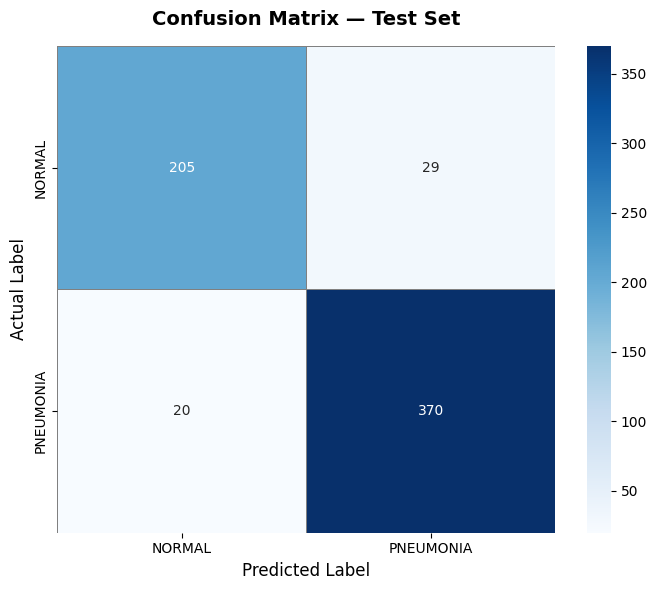


Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.91      0.88      0.89       234
   PNEUMONIA       0.93      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624



In [14]:
# Get predictions
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_generator.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_generator.class_indices.keys())

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
ax.set_title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Actual Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

## Step 13: ROC Curve

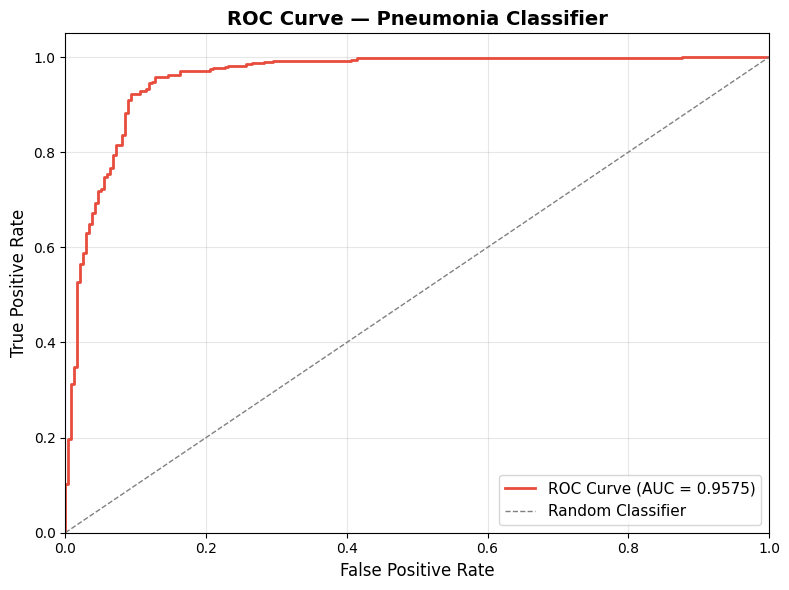


 AUC Score: 0.9575


In [15]:
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Pneumonia Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n AUC Score: {roc_auc:.4f}')

## Step 14: Visualize Predictions on Sample Images

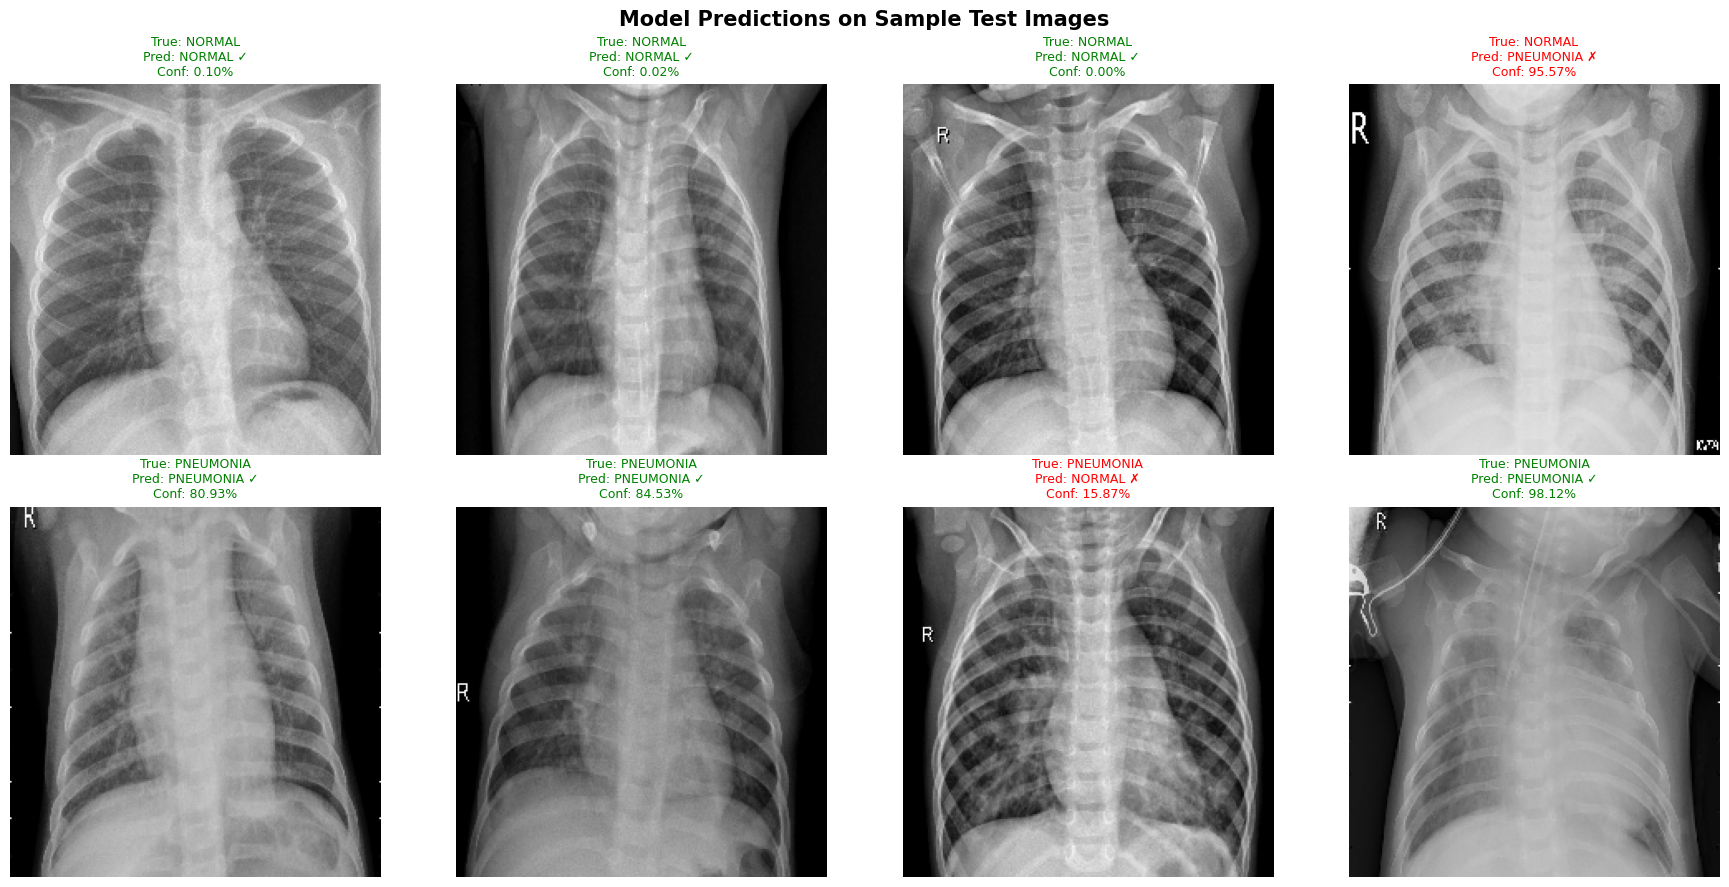

In [16]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_image(img_path, model, class_names):
    img = load_img(img_path, target_size=(224, 224))
    x   = img_to_array(img) / 255.0
    x   = np.expand_dims(x, axis=0)
    prob = model.predict(x, verbose=0)[0][0]
    pred = class_names[int(prob > 0.5)]
    return img, pred, prob

class_names = ['NORMAL', 'PNEUMONIA']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Model Predictions on Sample Test Images', fontsize=15, fontweight='bold')

for row, label in enumerate(['NORMAL', 'PNEUMONIA']):
    folder = os.path.join(TEST_DIR, label)
    sample_imgs = os.listdir(folder)[:4]
    for col, img_name in enumerate(sample_imgs):
        img_path = os.path.join(folder, img_name)
        img, pred, prob = predict_image(img_path, model, class_names)

        axes[row][col].imshow(img)
        correct = (pred == label)
        color   = 'green' if correct else 'red'
        status  = '✓' if correct else '✗'
        axes[row][col].set_title(
            f'True: {label}\nPred: {pred} {status}\nConf: {prob:.2%}',
            fontsize=9, color=color
        )
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

## Step 15: Save the Final Model

In [17]:

save_path = '/content/drive/MyDrive/pneumonia_classifier_final.keras'
model.save(save_path)
print(f'Model saved to Google Drive: {save_path}')


model.save('pneumonia_classifier_final.keras')
print('Model also saved locally.')

Model saved to Google Drive: /content/drive/MyDrive/pneumonia_classifier_final.keras
Model also saved locally.


## Summary

| Metric | Score |
|--------|-------|
| Architecture | VGG16 + Custom Head |
| Input Size | 224 × 224 × 3 |
| Classes | NORMAL / PNEUMONIA |
| Optimizer | Adam |
| Loss | Binary Crossentropy |

---
**Key Takeaways:**
- Transfer learning with VGG16 gives excellent accuracy on small medical datasets
- Class weighting handles the imbalance between NORMAL and PNEUMONIA samples
- Fine-tuning the last VGG16 layers improves performance further
- High Recall is critical in medical diagnosis to minimise missed Pneumonia cases